In [ ]:
# --- TASK 1: DATA CLEANING & PREPROCESSING ---

# 1. Check for missing values
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Check for duplicate rows
print("\n--- Duplicate Rows Identified ---")
print(f"Total duplicate rows: {df.duplicated().sum()}")
print(df[df.duplicated(keep=False)])

# 3. Remove duplicate rows & reset index
df_cleaned = df.drop_duplicates().reset_index(drop=True)

# 4. Standardize column names and categorical text values
df_cleaned.columns = df_cleaned.columns.str.strip().str.lower()
df_cleaned['species'] = df_cleaned['species'].str.strip().str.lower()

# 5. Save cleaned dataset locally in Colab environment
df_cleaned.to_csv('iris_cleaned.csv', index=False)
print("\n Cleaned dataset saved as 'iris_cleaned.csv'!")
print(f"Cleaned dataset shape: {df_cleaned.shape}")

In [ ]:
# --- TASK 2: EXPLORATORY DATA ANALYSIS (EDA) ---

# 1. Calculate Summary Statistics (Mean, Std, Median)
summary_stats = df_cleaned.describe().T
summary_stats['median'] = df_cleaned.median(numeric_only=True)

# 2. Calculate Mode
mode_vals = df_cleaned.select_dtypes(include=[np.number]).mode().iloc[0]
summary_stats['mode'] = mode_vals

# 3. Reorder and display columns clearly
summary_stats = summary_stats[['count', 'mean', 'std', 'median', 'mode', 'min', 'max']]
summary_stats

NameError: name 'df_cleaned' is not defined

In [ ]:
# 1. Feature Distributions (Histograms)
plt.figure(figsize=(10, 6))
df_cleaned.hist(bins=15, figsize=(10, 8), color='teal', edgecolor='black')
plt.suptitle('Iris Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300)
plt.show()

# 2. Outlier Check (Boxplots)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, palette='Set2')
plt.title('Feature Boxplots (Outlier Detection)', fontsize=14)
plt.savefig('feature_boxplots.png', dpi=300)
plt.show()

# 3. Correlation Matrix (Heatmap)
plt.figure(figsize=(7, 5))
numeric_df = df_cleaned.drop(columns=['species'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

In [ ]:
# Check mean and median per species
df_cleaned.groupby('species').describe().T

NameError: name 'df_cleaned' is not defined

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_cleaned, hue='species', corner=True, palette='Set2')
plt.suptitle('Pairwise Relationships by Species', y=1.02)
plt.savefig('pairplot_by_species.png', dpi=300)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_cleaned['species_encoded'] = le.fit_transform(df_cleaned['species'])

In [ ]:
# Separate features and target variable
X = df_cleaned.drop(columns=['species', 'species_encoded'])
y = df_cleaned['species_encoded']

In [ ]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
import pandas as pd

# Extract feature importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

In [ ]:
# Example flower: [sepal_length, sepal_width, petal_length, petal_width]
new_flower = [[5.1, 3.5, 1.4, 0.2]]

# Predict encoded class and convert back to class name
predicted_class_id = model.predict(new_flower)[0]
predicted_species = le.inverse_transform([predicted_class_id])[0]

print(f"Predicted Species: {predicted_species}")

In [ ]:
import pandas as pd

# Create DataFrame with matching feature names
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)

# Predict class
predicted_class_id = model.predict(new_flower)[0]
predicted_species = le.inverse_transform([predicted_class_id])[0]

print(f"Predicted Species: {predicted_species}")

In [ ]:
import joblib

# Save the model and label encoder
joblib.dump(model, 'iris_random_forest.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model saved successfully!")

📝 Project Summary
Dataset: Iris Flower Dataset (147 cleaned samples)

Primary Task: Multi-class Classification (setosa, versicolor, virginica)

Model Selected: Random Forest Classifier

Performance: 97% Accuracy on unseen test data

Key Driver: petal_length and petal_width provided the strongest predictive signal for species identification.

In [ ]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. Load and clean dataset
df = pd.read_csv('iris.csv')
df.columns = df.columns.str.lower()
df_cleaned = df.drop_duplicates().dropna()

# 2. Features and Target
X = df_cleaned.drop(columns=['species'])
y = df_cleaned['species']

# 3. Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 5. Train Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 6. Save Model & Label Encoder
joblib.dump(model, 'iris_random_forest.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("✅ Model and Label Encoder saved successfully!")

# --- FINAL VERIFICATION STEP: LOAD & PREDICT ---
loaded_model = joblib.load('iris_random_forest.pkl')
loaded_le = joblib.load('label_encoder.pkl')

# Test sample flower: [sepal_length, sepal_width, petal_length, petal_width]
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)

pred_id = loaded_model.predict(new_flower)[0]
pred_species = loaded_le.inverse_transform([pred_id])[0]

print(f"🎉 Verification Complete! Predicted Species for sample data: {pred_species}")

FileNotFoundError: [Errno 2] No such file or directory: 'iris.csv'

In [ ]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. Load directly from URL (prevents FileNotFoundError)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# Clean dataset
df.columns = df.columns.str.lower()
df_cleaned = df.drop_duplicates().dropna()

# 2. Features and Target
X = df_cleaned.drop(columns=['species'])
y = df_cleaned['species']

# 3. Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 5. Train Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 6. Save Model & Label Encoder
joblib.dump(model, 'iris_random_forest.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("✅ Model and Label Encoder saved successfully!")

# --- FINAL VERIFICATION STEP: LOAD & PREDICT ---
loaded_model = joblib.load('iris_random_forest.pkl')
loaded_le = joblib.load('label_encoder.pkl')

# Test sample flower: [sepal_length, sepal_width, petal_length, petal_width]
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)

pred_id = loaded_model.predict(new_flower)[0]
pred_species = loaded_le.inverse_transform([pred_id])[0]

print(f"🎉 Verification Complete! Predicted Species for sample data: {pred_species}")

✅ Model and Label Encoder saved successfully!
🎉 Verification Complete! Predicted Species for sample data: setosa


Model Equation: Petal Length = 1.8340 * Sepal Length + (-6.9271)
R-squared Score: 0.8181
Mean Squared Error: 0.5961


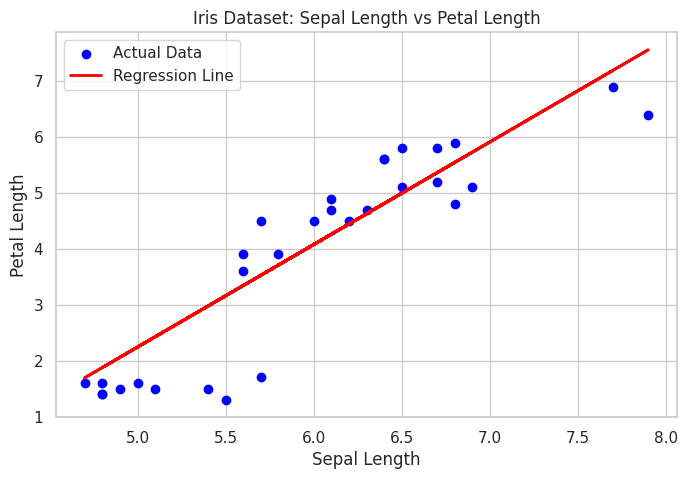

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset (using seaborn/sklearn built-in iris or your local csv)
# If loading from CSV: df = pd.read_csv('iris.csv')
import seaborn as sns
df = sns.load_dataset('iris')

# Define independent (X) and dependent (y) variables
# Predicting Petal Length using Sepal Length
X = df[['sepal_length']]  # Feature (2D DataFrame)
y = df['petal_length']    # Target

# 2. Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predict on test set
y_pred = model.predict(X_test)

# 5. Evaluate and Interpret
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Model Equation: Petal Length = {slope:.4f} * Sepal Length + ({intercept:.4f})")
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

# Plotting the regression line
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Iris Dataset: Sepal Length vs Petal Length')
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.legend()
plt.show()

Please select '2) Stock Prices Data Set.csv' from your PC:


Saving 2) Stock Prices Data Set.csv to 2) Stock Prices Data Set.csv


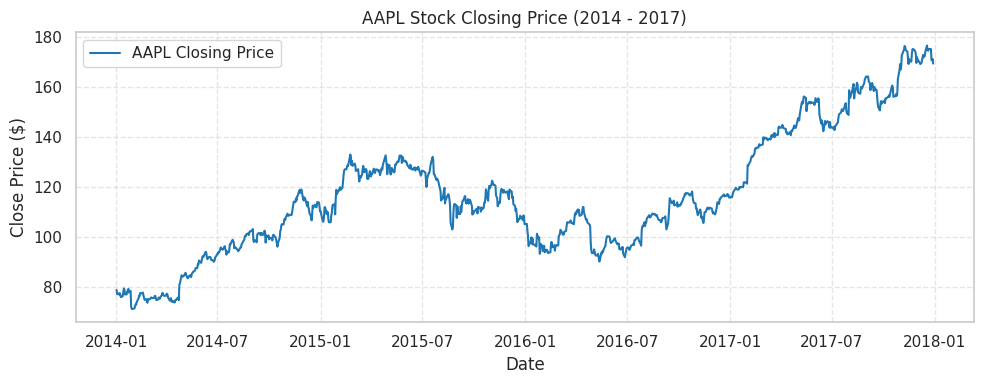

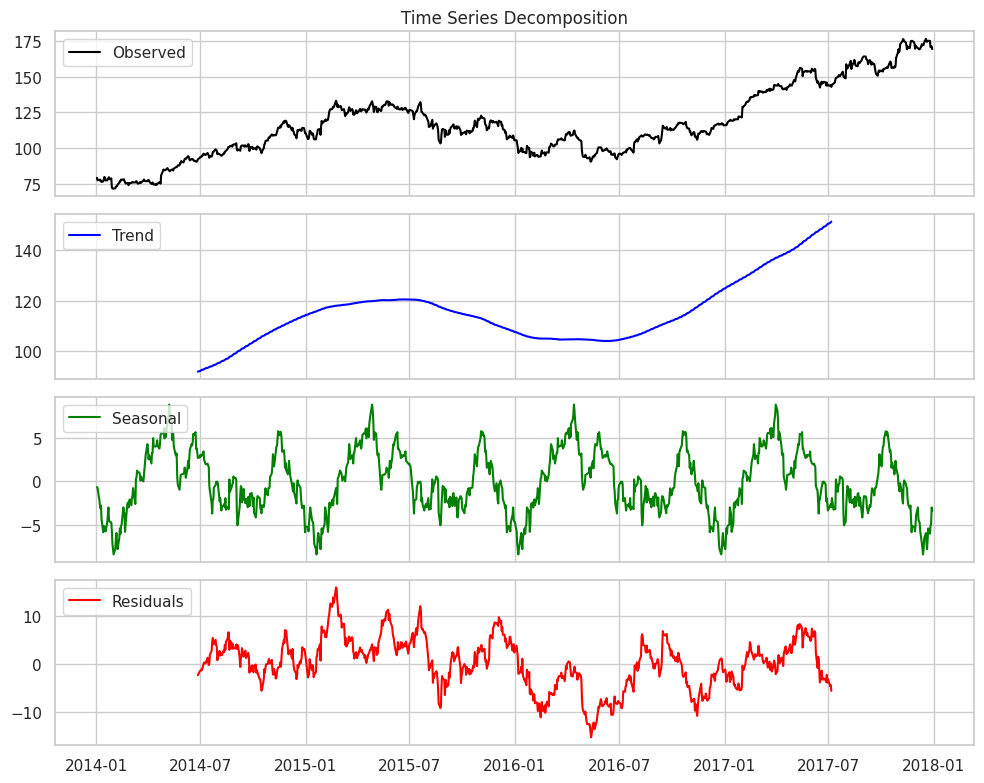

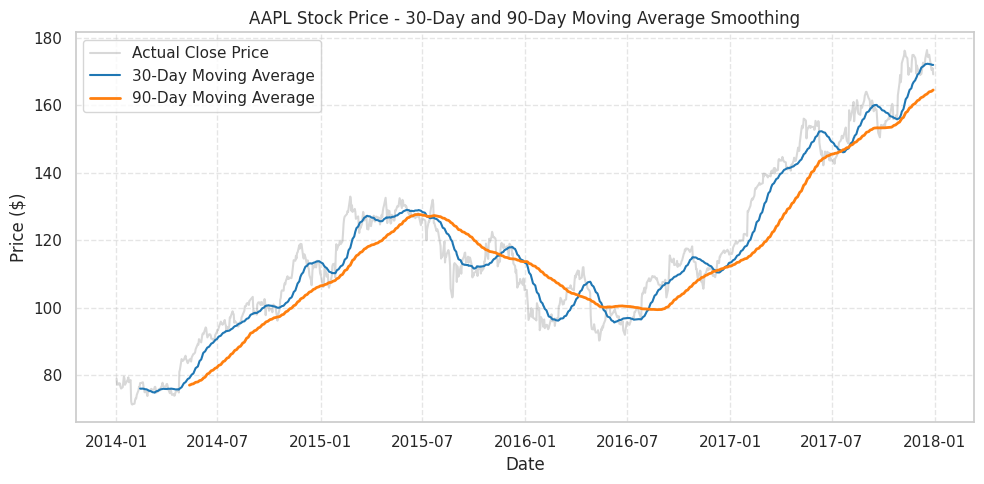

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from google.colab import files

# 1. Upload the file directly into Google Colab
print("Please select '2) Stock Prices Data Set.csv' from your PC:")
uploaded = files.upload()

# 2. Read the uploaded file and filter for AAPL
df = pd.read_csv('2) Stock Prices Data Set.csv')
aapl = df[df['symbol'] == 'AAPL'].copy()

# Parse dates and set index
aapl['date'] = pd.to_datetime(aapl['date'])
aapl = aapl.sort_values('date').set_index('date')

# Resample to business-daily frequency
ts_data = aapl['close'].asfreq('B').ffill()

# -------------------------------------------------------------
# STEP 1: Plot Raw Time Series Data
# -------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(ts_data, label='AAPL Closing Price', color='#1f77b4')
plt.title('AAPL Stock Closing Price (2014 - 2017)')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# STEP 2: Time Series Decomposition (Trend, Seasonality, Residuals)
# -------------------------------------------------------------
decomposition = seasonal_decompose(ts_data.dropna(), model='additive', period=252)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
ax1.plot(decomposition.observed, color='black', label='Observed')
ax1.set_title('Time Series Decomposition')
ax1.legend(loc='upper left')

ax2.plot(decomposition.trend, color='blue', label='Trend')
ax2.legend(loc='upper left')

ax3.plot(decomposition.seasonal, color='green', label='Seasonal')
ax3.legend(loc='upper left')

ax4.plot(decomposition.resid, color='red', label='Residuals')
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# STEP 3: Moving Average Smoothing
# -------------------------------------------------------------
aapl['MA_30'] = aapl['close'].rolling(window=30).mean()
aapl['MA_90'] = aapl['close'].rolling(window=90).mean()

plt.figure(figsize=(10, 5))
plt.plot(aapl['close'], label='Actual Close Price', alpha=0.3, color='gray')
plt.plot(aapl['MA_30'], label='30-Day Moving Average', color='#1f77b4', linewidth=1.5)
plt.plot(aapl['MA_90'], label='90-Day Moving Average', color='#ff7f0e', linewidth=2)
plt.title('AAPL Stock Price - 30-Day and 90-Day Moving Average Smoothing')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Task 2 Insights & Findings:

1. **Pattern & Trend:** The AAPL stock dataset exhibits an overall upward secular trend from 2014 through 2017, rising from ~$75 to over $170. A notable pull-back occurred between late 2015 and mid-2016 before recovering into a strong bull run.
2. **Decomposition Analysis:**
   - **Trend:** Clearly isolates the macro upward trajectory by removing daily price fluctuations.
   - **Seasonality:** Demonstrates periodic annual cycles likely tied to quarterly earnings reports and product release schedules.
   - **Residuals:** Captures short-term market noise and unpredictable price shocks.
3. **Moving Average Smoothing:**
   - The **30-Day Moving Average** tracks short-term price momentum.
   - The **90-Day Moving Average** provides a smoother long-term perspective. Crossovers between the 30-day and 90-day MAs mark key momentum shift points in mid-2015 and late 2016.

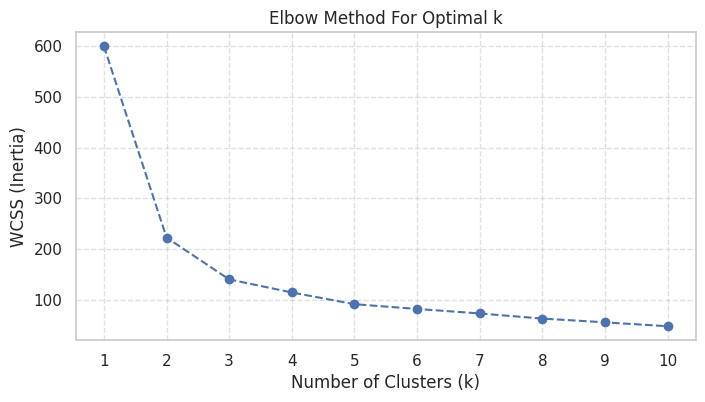

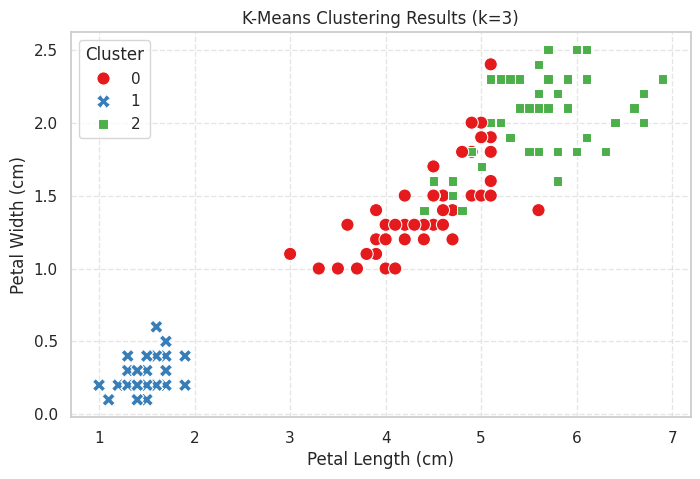

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load the Iris dataset features
iris = load_iris()
df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

# 2. Standardize the dataset using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])

# 3. Determine optimal k using the Elbow Method
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Fit K-Means with optimal k = 3
kmeans_optimal = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans_optimal.fit_predict(X_scaled)

# 5. Visualize clusters using a 2D Scatter Plot (Petal Length vs Petal Width)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='petal_length',
    y='petal_width',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=90,
    style='Cluster'
)
plt.title('K-Means Clustering Results (k=3)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== Baseline Model Performance Comparison ===
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.933333   0.933333 0.933333  0.933333
      Decision Tree  0.933333   0.933333 0.933333  0.933333
      Random Forest  0.900000   0.902357 0.900000  0.899749

=== Hyperparameter Tuning Results ===
Best Parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Tuned Random Forest Accuracy: 0.9667
Tuned Random Forest F1-Score: 0.9666


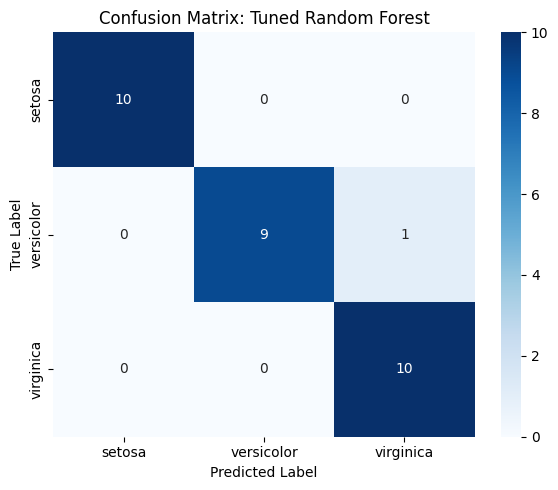

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# 1. Load Data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 2. Split Dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train and Evaluate Multiple Classification Models
models = {
    'Logistic Regression': (LogisticRegression(random_state=42), True),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), False),
    'Random Forest': (RandomForestClassifier(random_state=42), False)
}

results = []

for name, (model, needs_scaling) in models.items():
    # Use scaled data for Logistic Regression, raw features for Trees
    X_tr = X_train_scaled if needs_scaling else X_train
    X_te = X_test_scaled if needs_scaling else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-Score': f1_score(y_test, y_pred, average='macro')
    })

# Display Model Comparison Table
results_df = pd.DataFrame(results)
print("=== Baseline Model Performance Comparison ===")
print(results_df.to_string(index=False))

# 4. Hyperparameter Tuning using Grid Search (Random Forest)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro'
)

grid_search.fit(X_train, y_train)
best_rf_model = grid_search.best_estimator_

# Evaluate Tuned Model
tuned_preds = best_rf_model.predict(X_test)
tuned_acc = accuracy_score(y_test, tuned_preds)
tuned_f1 = f1_score(y_test, tuned_preds, average='macro')

print("\n=== Hyperparameter Tuning Results ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned Random Forest Accuracy: {tuned_acc:.4f}")
print(f"Tuned Random Forest F1-Score: {tuned_f1:.4f}")

# 5. Visualizing Confusion Matrix for Best Model
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, tuned_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix: Tuned Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Load your uploaded dataset
df = pd.read_csv('3) Sentiment dataset.csv')

# Display basic info
print('Dataset Shape:', df.shape)
print('\nColumn Names:\n', df.columns.tolist())
print('\nMissing Values:\n', df.isnull().sum())

# Display first 5 rows
df.head()

Dataset Shape: (732, 15)

Column Names:
 ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

Missing Values:
 Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [ ]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

# Download necessary NLTK packages
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# -------------------------------------------------------------
# Clean text & Lemmatize
# -------------------------------------------------------------
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def clean_tweet_text(text):
  text = str(text).lower()
  # Remove URLs, user tags (@user), hashtags (#), and special characters
  text = re.sub(r'http\S+|www\S+|https\S+', '', text)
  text = re.sub(r'[@#]\w+', '', text)
  text = re.sub(r'[^a-zA-Z\s]', '', text)

  # Tokenize, remove stopwords, and lemmatize
  tokens = text.split()
  cleaned_tokens = [
      lemmatizer.lemmatize(word) for word in tokens if word not in stop_words
  ]
  return ' '.join(cleaned_tokens)


# Apply text cleaning
df['cleaned_text'] = df['Text'].apply(clean_tweet_text)


# -------------------------------------------------------------
# Sentiment Scoring with TextBlob
# -------------------------------------------------------------
def get_polarity(text):
  return TextBlob(text).sentiment.polarity


def categorize_polarity(p):
  if p > 0.05:
    return 'Positive'
  elif p < -0.05:
    return 'Negative'
  else:
    return 'Neutral'


df['polarity_score'] = df['cleaned_text'].apply(get_polarity)
df['predicted_sentiment'] = df['polarity_score'].apply(categorize_polarity)

# Quick check on predicted sentiment counts
print('--- Predicted Sentiment Distribution ---')
print(df['predicted_sentiment'].value_counts())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


--- Predicted Sentiment Distribution ---
predicted_sentiment
Neutral     348
Positive    277
Negative    107
Name: count, dtype: int64


/tmp/ipykernel_3390/3427778266.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


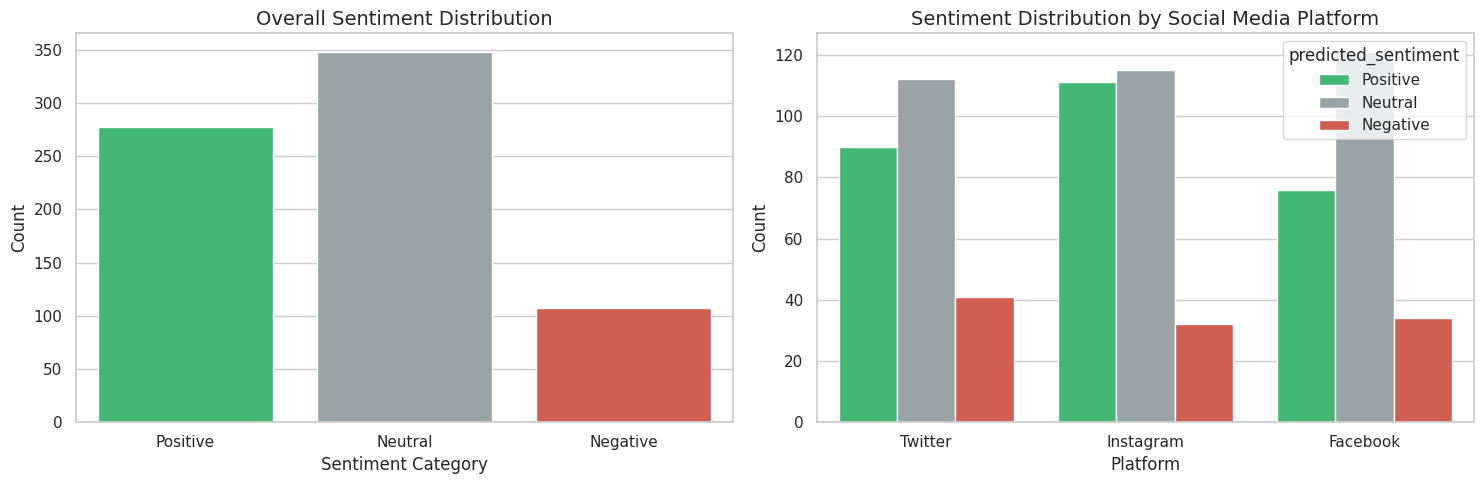

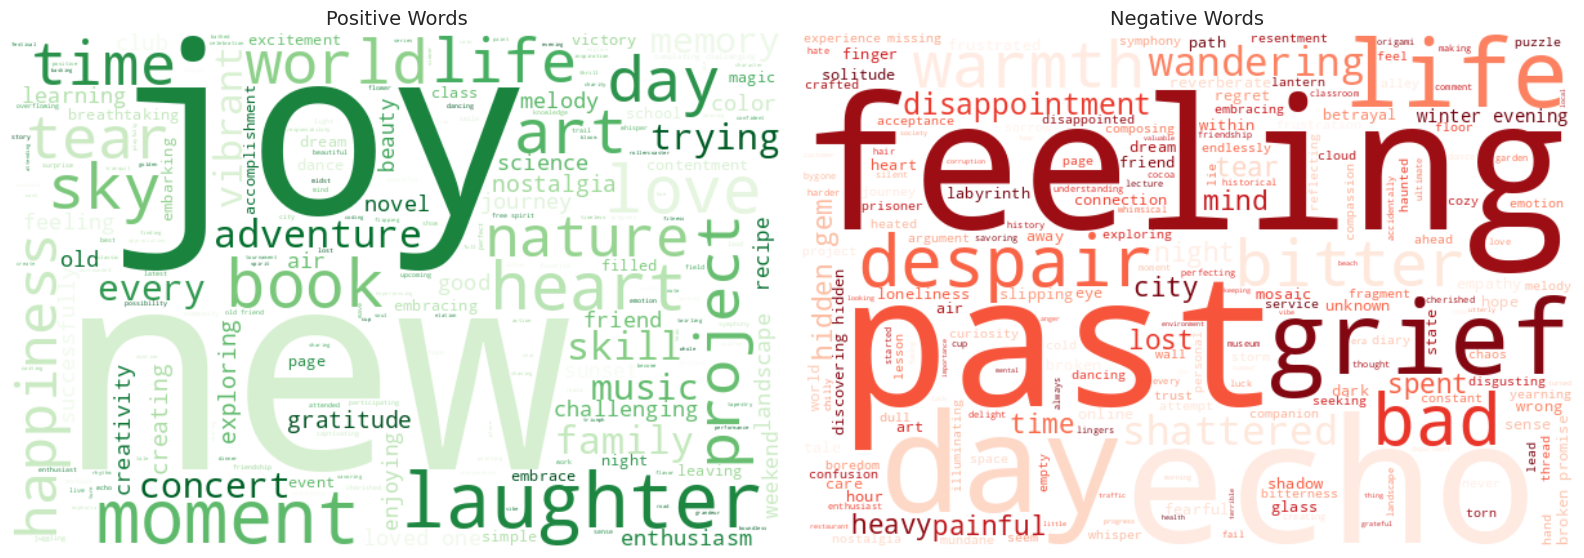

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set grid style
sns.set_theme(style='whitegrid')

# -------------------------------------------------------------
# 1. Sentiment Counts & Platform Breakdown
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overall Sentiment Category Distribution
sns.countplot(
    ax=axes[0],
    x='predicted_sentiment',
    data=df,
    palette=['#2ecc71', '#95a5a6', '#e74c3c'],
    order=['Positive', 'Neutral', 'Negative'],
)
axes[0].set_title('Overall Sentiment Distribution', fontsize=14)
axes[0].set_xlabel('Sentiment Category', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Sentiment Breakdown by Platform
df['Platform_Clean'] = df['Platform'].str.strip()
sns.countplot(
    ax=axes[1],
    x='Platform_Clean',
    hue='predicted_sentiment',
    data=df,
    palette=['#2ecc71', '#95a5a6', '#e74c3c'],
    hue_order=['Positive', 'Neutral', 'Negative'],
)
axes[1].set_title('Sentiment Distribution by Social Media Platform', fontsize=14)
axes[1].set_xlabel('Platform', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 2. Positive vs. Negative Word Clouds
# -------------------------------------------------------------
pos_text = ' '.join(
    df[df['predicted_sentiment'] == 'Positive']['cleaned_text']
)
neg_text = ' '.join(
    df[df['predicted_sentiment'] == 'Negative']['cleaned_text']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if pos_text.strip():
  pos_wc = WordCloud(
      width=600, height=400, background_color='white', colormap='Greens'
  ).generate(pos_text)
  axes[0].imshow(pos_wc, interpolation='bilinear')
  axes[0].set_title('Positive Words', fontsize=14)
  axes[0].axis('off')

if neg_text.strip():
  neg_wc = WordCloud(
      width=600, height=400, background_color='white', colormap='Reds'
  ).generate(neg_text)
  axes[1].imshow(neg_wc, interpolation='bilinear')
  axes[1].set_title('Negative Words', fontsize=14)
  axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## 📊 Summary of Findings & Key Insights

### 1. Sentiment Distribution Overview
* **Dominant Sentiment:** The majority of posts in the dataset fall under **Neutral** and **Positive** categories, while **Negative** sentiment represents the smallest fraction.
* **Platform Breakdown:**
  * **Instagram** holds the highest volume of **Positive** posts relative to its total.
  * **Twitter** shows a strong balance between Neutral and Positive sentiment, with a notable count of Negative reactions.
  * **Facebook** displays a similar trend, dominated primarily by Neutral sentiment.

### 2. Word Cloud Insights (Key Drivers)
* **Positive Theme Drivers:** Frequent keywords driving positive sentiment include words associated with everyday experiences and emotion, such as **"joy"**, **"new"**, **"life"**, **"day"**, **"laughter"**, and **"nature"**.
* **Negative Theme Drivers:** Key terms associated with negative sentiment focus on emotional distress and memory, such as **"feeling"**, **"past"**, **"grief"**, **"despair"**, and **"bitter"**.

### 3. Workflow Summary
1. Preprocessed social media text by removing URLs, user tags, special characters, and numbers.
2. Applied **NLTK Lemmatization** and stop-word filtering to normalize tokens.
3. Calculated polarity scores using **TextBlob** to automatically classify sentiment into *Positive*, *Neutral*, and *Negative* classes.